In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("/content/BlackFridaySales.csv")

In [3]:
data.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category_1,Product_Category_2,Product_Category_3,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,NaN,NaN,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,6.0,14.0,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,NaN,NaN,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,14.0,NaN,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,NaN,NaN,7969


In [4]:
data.shape

(550068, 12)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 550068 entries, 0 to 550067
Data columns (total 12 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   User_ID                     550068 non-null  int64  
 1   Product_ID                  550068 non-null  object 
 2   Gender                      550068 non-null  object 
 3   Age                         550068 non-null  object 
 4   Occupation                  550068 non-null  int64  
 5   City_Category               550068 non-null  object 
 6   Stay_In_Current_City_Years  550068 non-null  object 
 7   Marital_Status              550068 non-null  int64  
 8   Product_Category_1          550068 non-null  int64  
 9   Product_Category_2          376430 non-null  float64
 10  Product_Category_3          166821 non-null  float64
 11  Purchase                    550068 non-null  int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 50.4+ MB


In [6]:
data.isnull().sum()

,0
User_ID,0
Product_ID,0
Gender,0
Age,0
Occupation,0
City_Category,0
Stay_In_Current_City_Years,0
Marital_Status,0
Product_Category_1,0
Product_Category_2,173638


In [7]:
data.isnull().sum()/data.shape[0]*100

,0
User_ID,0.000000
Product_ID,0.000000
Gender,0.000000
Age,0.000000
Occupation,0.000000
City_Category,0.000000
Stay_In_Current_City_Years,0.000000
Marital_Status,0.000000
Product_Category_1,0.000000
Product_Category_2,31.566643


In [8]:
data.nunique()

,0
User_ID,5891
Product_ID,3631
Gender,2
Age,7
Occupation,21
City_Category,3
Stay_In_Current_City_Years,5
Marital_Status,2
Product_Category_1,20
Product_Category_2,17


/tmp/ipykernel_63383/2016751557.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data["Purchase"],color='r')


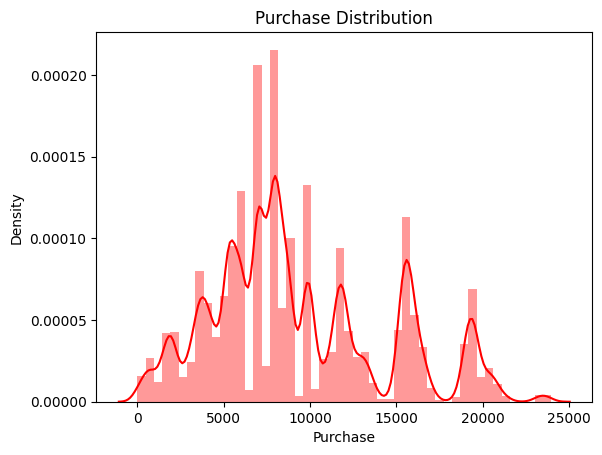

In [9]:
sns.distplot(data["Purchase"],color='r')
plt.title("Purchase Distribution")
plt.show()

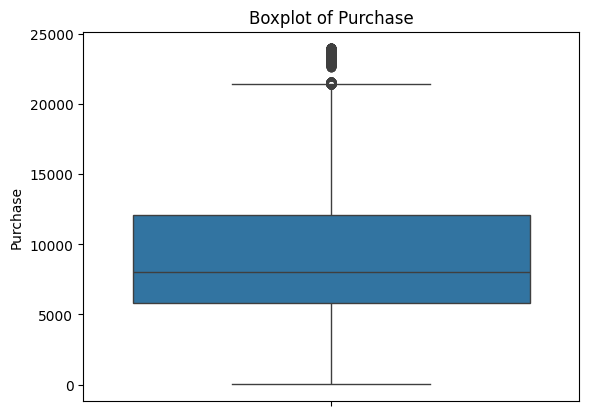

In [10]:
sns.boxplot(data["Purchase"])
plt.title("Boxplot of Purchase")
plt.show()

In [11]:
data["Purchase"].skew()

np.float64(0.6001400037087128)

In [12]:
data["Purchase"].kurtosis()

np.float64(-0.3383775655851702)

In [13]:
data["Purchase"].describe()

,Purchase
count,550068.000000
mean,9263.968713
std,5023.065394
min,12.000000
25%,5823.000000
50%,8047.000000
75%,12054.000000
max,23961.000000


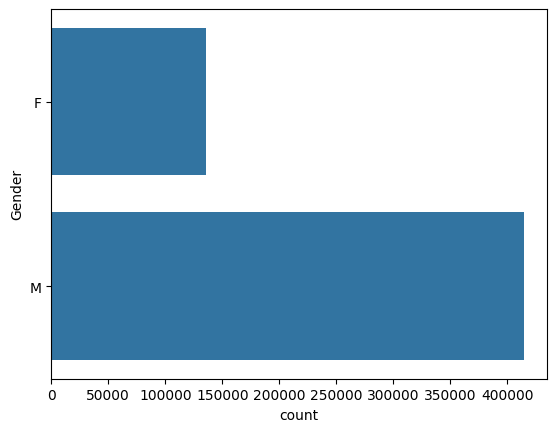

In [14]:
sns.countplot(data['Gender'])
plt.show()

In [15]:
data['Gender'].value_counts(normalize=True)*100

,proportion
Gender,
M,75.310507
F,24.689493


In [16]:
data.groupby("Gender")["Purchase"].mean()

,Purchase
Gender,
F,8734.565765
M,9437.526040


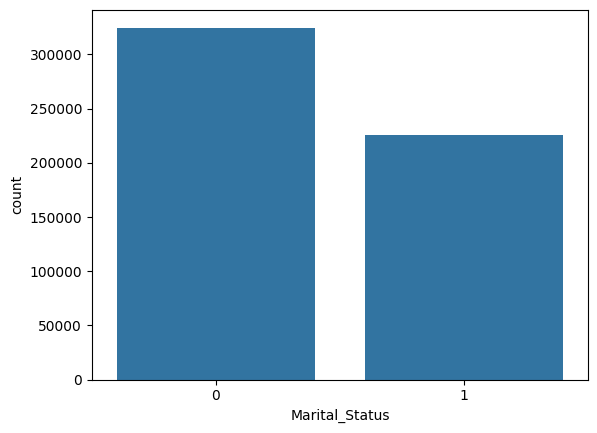

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Marital_Status', data=data)
plt.show()

In [18]:
data.groupby('Marital_Status')['Purchase'].mean()

,Purchase
Marital_Status,
0,9265.907619
1,9261.174574


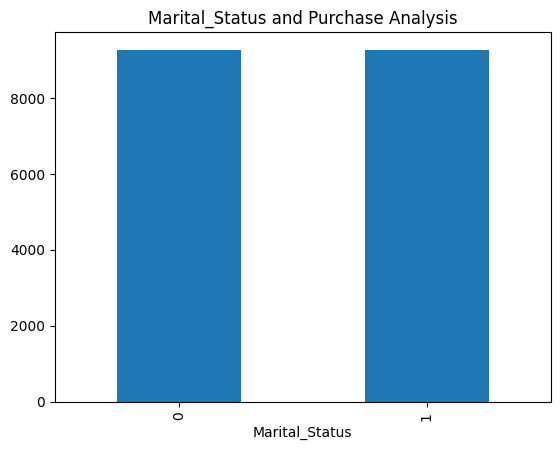

In [19]:
data.groupby('Marital_Status')['Purchase'].mean().plot(kind='bar')
plt.title("Marital_Status and Purchase Analysis")
plt.show()

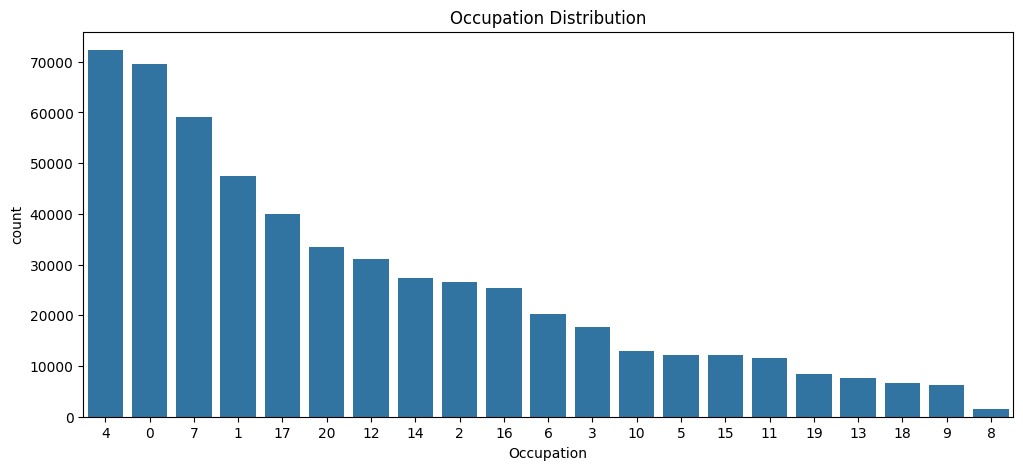

In [20]:
plt.figure(figsize=(12,5))

order = data['Occupation'].value_counts().index
sns.countplot(x='Occupation', data=data, order=order)

plt.title("Occupation Distribution")
plt.show()

In [21]:
data['Purchase'] = pd.to_numeric(data['Purchase'], errors='coerce')
data.dropna(subset=['Purchase'], inplace=True)

occup = data.groupby('Occupation')['Purchase'].mean().reset_index()

print(occup)

    Occupation     Purchase
0            0  9124.428588
1            1  8953.193270
2            2  8952.481683
3            3  9178.593088
4            4  9213.980251
5            5  9333.149298
6            6  9256.535691
7            7  9425.728223
8            8  9532.592497
9            9  8637.743761
10          10  8959.355375
11          11  9213.845848
12          12  9796.640239
13          13  9306.351061
14          14  9500.702772
15          15  9778.891163
16          16  9394.464349
17          17  9821.478236
18          18  9169.655844
19          19  8710.627231
20          20  8836.494905


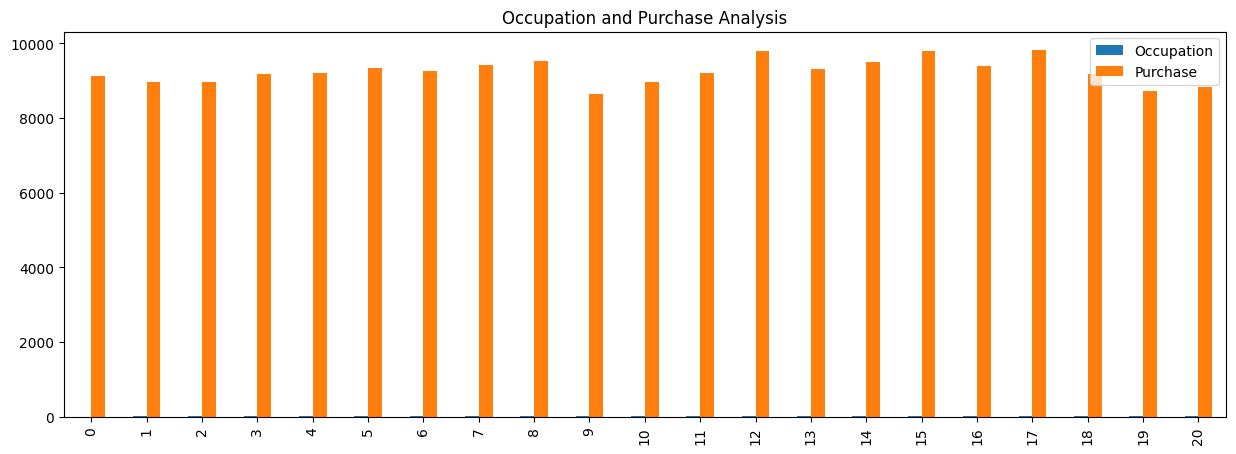

In [22]:
occup.plot(kind='bar',figsize=(15,5))
plt.title("Occupation and Purchase Analysis")
plt.show()

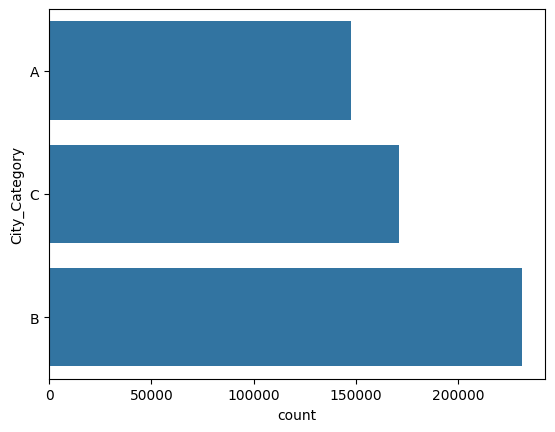

In [23]:
sns.countplot(data['City_Category'])
plt.show()

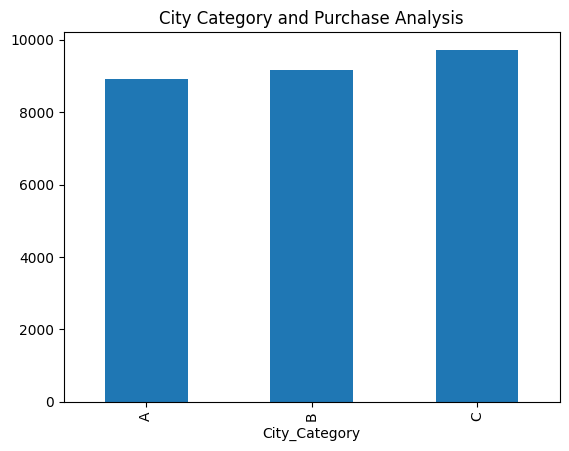

In [24]:
data.groupby('City_Category')['Purchase'].mean().plot(kind='bar')
plt.title("City Category and Purchase Analysis")
plt.show()

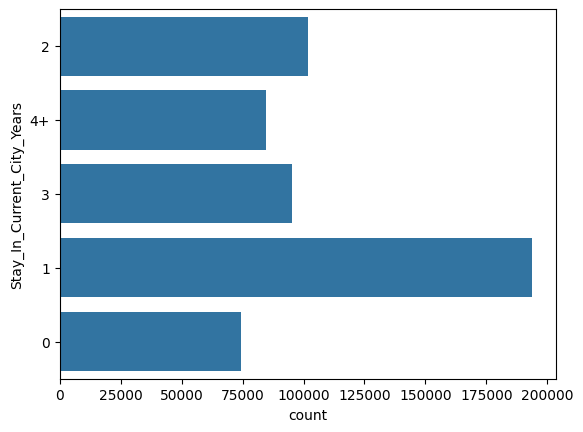

In [25]:
sns.countplot(data['Stay_In_Current_City_Years'])
plt.show()

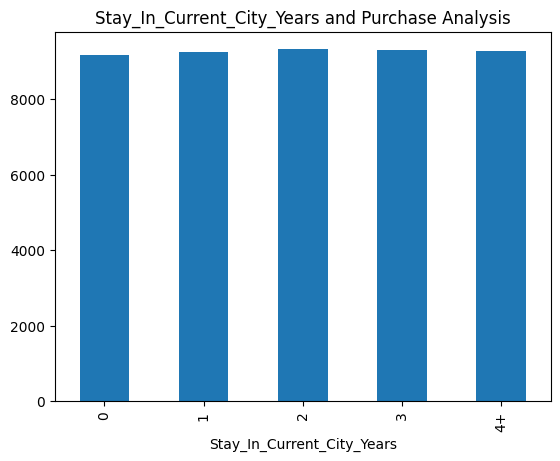

In [26]:
data.groupby("Stay_In_Current_City_Years")["Purchase"].mean().plot(kind='bar')
plt.title("Stay_In_Current_City_Years and Purchase Analysis")
plt.show()

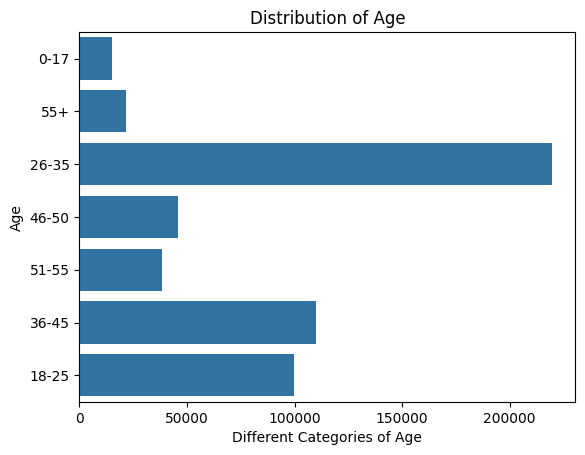

In [27]:
sns.countplot(data['Age'])
plt.title('Distribution of Age')
plt.xlabel('Different Categories of Age')
plt.show()

<Axes: xlabel='Age'>

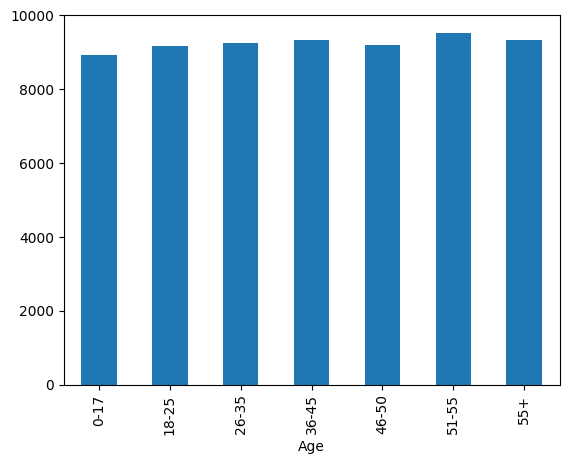

In [28]:
data.groupby("Age")["Purchase"].mean().plot(kind='bar')

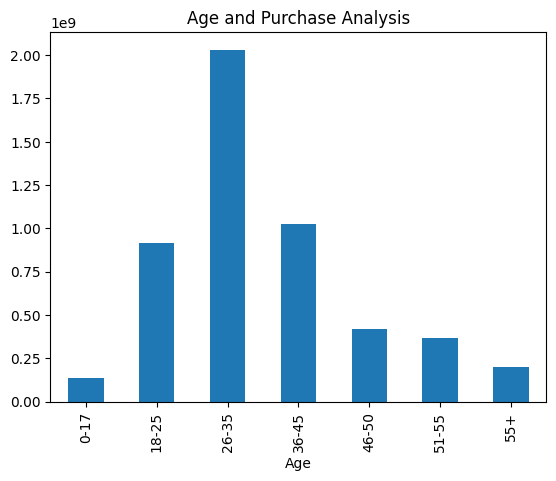

In [29]:
data.groupby("Age")['Purchase'].sum().plot(kind="bar")
plt.title("Age and Purchase Analysis")
plt.show()

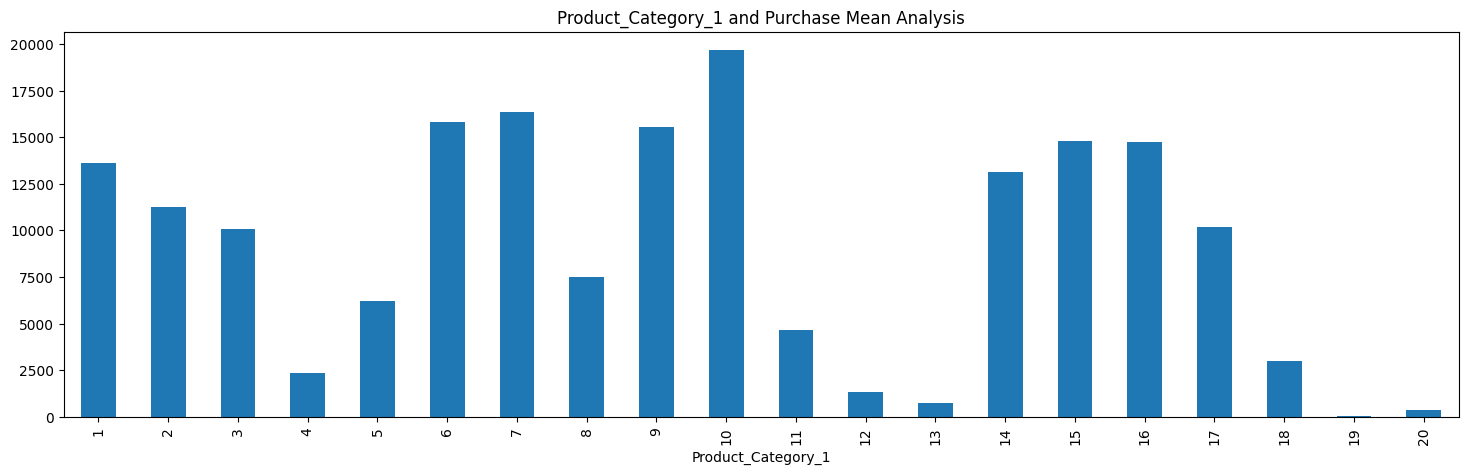

In [30]:
data.groupby('Product_Category_1')['Purchase'].mean().plot(kind='bar',figsize=(18,5))
plt.title("Product_Category_1 and Purchase Mean Analysis")
plt.show()

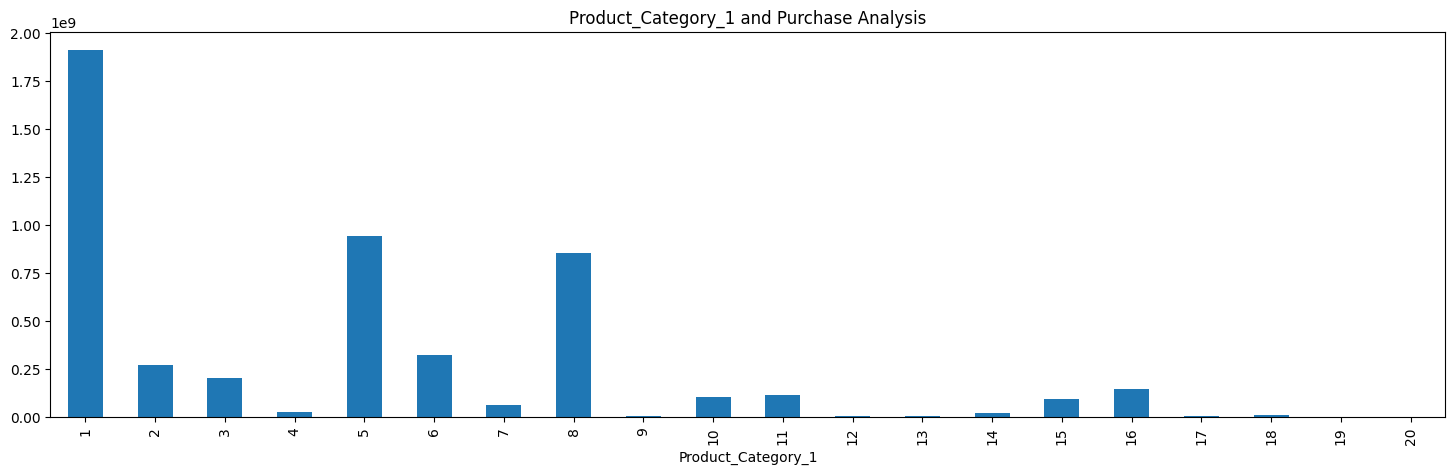

In [31]:
data.groupby('Product_Category_1')['Purchase'].sum().plot(kind='bar',figsize=(18,5))
plt.title("Product_Category_1 and Purchase Analysis")
plt.show()

In [1]:
data.corr()

NameError: name 'data' is not defined